In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Ventas_Digital_Mensual_Limpia.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Digital         9 non-null      str    
 1   Febrero, 24     4 non-null      float64
 2   Marzo, 24       6 non-null      float64
 3   Abril, 24       5 non-null      float64
 4   Mayo, 24        5 non-null      float64
 5   Junio, 24       6 non-null      float64
 6   Julio, 24       6 non-null      float64
 7   Agosto, 24      5 non-null      float64
 8   Septiembre, 24  7 non-null      float64
 9   Octubre, 24     7 non-null      float64
 10  Noviembre, 24   7 non-null      float64
 11  Diciembre, 24   7 non-null      float64
 12  Enero, 25       8 non-null      float64
 13  Febrero, 25     8 non-null      float64
 14  Marzo, 25       8 non-null      float64
 15  Abril, 25       8 non-null      float64
 16  Mayo, 25        8 non-null      float64
 17  Junio, 25       8 non-null      float64
 18  Julio

Debido a la forma del data ser, los outliers al sacarse por columna, pero cada fila siendo una variable. Se decide normalizar la base de datos a un formato tidy.

In [6]:
df_tidy = data.set_index('Digital ').T.reset_index()

df_tidy = df_tidy.rename(columns={
    'index': 'Fecha'
})

In [7]:
df_tidy.head()

Digital,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",57.0,NaN,NaN,NaN,3.0,2.0,NaN,0.000000,NaN
1,"Marzo, 24",145.0,NaN,NaN,NaN,6.0,5.0,1.0,0.006897,0.083333
2,"Abril, 24",129.0,NaN,NaN,NaN,23.0,5.0,NaN,0.000000,0.000000
3,"Mayo, 24",463.0,NaN,NaN,NaN,43.0,23.0,NaN,0.000000,0.000000
4,"Junio, 24",350.0,NaN,NaN,NaN,43.0,19.0,1.0,0.002857,0.076923


In [19]:
df_tidy.head()

Digital,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",57.0,NaN,NaN,NaN,3.0,2.0,NaN,0.000000,NaN
1,"Marzo, 24",145.0,NaN,NaN,NaN,6.0,5.0,1.0,0.006897,0.083333
2,"Abril, 24",129.0,NaN,NaN,NaN,23.0,5.0,NaN,0.000000,0.000000
3,"Mayo, 24",463.0,NaN,NaN,NaN,43.0,23.0,NaN,0.000000,0.000000
4,"Junio, 24",350.0,NaN,NaN,NaN,43.0,19.0,1.0,0.002857,0.076923


División de las columnas cualitativas y cuantitativas para la búsqueda de los outliers

In [27]:
#Creo 2 dataframe para poder procesar los outliers, separando las variables cualitativas de las cuantitativas
cualitativas = df_tidy['Fecha']
cuantitativas = df_tidy.iloc[:, 1:11]

In [28]:
#Se corroboran los dataframes creados
cualitativas.head()

0    Febrero, 24
1      Marzo, 24
2      Abril, 24
3       Mayo, 24
4      Junio, 24
Name: Fecha, dtype: str

In [29]:
#Se corroboran los dataframes creados
cuantitativas.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Leads              30 non-null     float64
 1   Efectivos          12 non-null     float64
 2   SDC                19 non-null     float64
 3   PDM                23 non-null     float64
 4   Citas Programadas  30 non-null     float64
 5   Citas Efectivas    30 non-null     float64
 6   Ventas             26 non-null     float64
 7   Conversion         30 non-null     float64
 8   Aporte             29 non-null     float64
dtypes: float64(9)
memory usage: 2.2 KB


Identificamos outliers

<Figure size 1500x800 with 0 Axes>

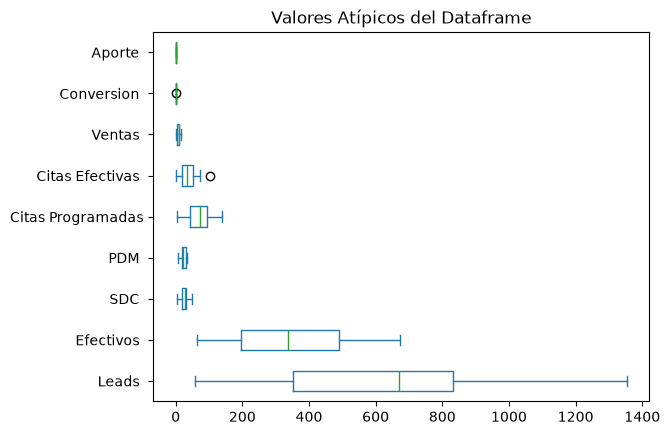

In [30]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [31]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Digital 
Leads                1551.500000
Efectivos             936.000000
SDC                    51.250000
PDM                    45.250000
Citas Programadas     173.625000
Citas Efectivas        99.000000
Ventas                 17.500000
Conversion              0.038111
Aporte                  0.624494
dtype: float64
Limite inferior permitido Digital 
Leads               -366.500000
Efectivos           -250.000000
SDC                   -2.750000
PDM                    3.250000
Citas Programadas    -35.375000
Citas Efectivas      -29.000000
Ventas                -2.500000
Conversion            -0.015181
Aporte                -0.128543
dtype: float64


In [32]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr

Digital,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,57.0,NaN,NaN,NaN,3.0,2.0,NaN,0.000000,NaN
1,145.0,NaN,NaN,NaN,6.0,5.0,1.0,0.006897,0.083333
2,129.0,NaN,NaN,NaN,23.0,5.0,NaN,0.000000,0.000000
3,463.0,NaN,NaN,NaN,43.0,23.0,NaN,0.000000,0.000000
4,350.0,NaN,NaN,NaN,43.0,19.0,1.0,0.002857,0.076923
5,192.0,NaN,NaN,NaN,36.0,14.0,2.0,0.010417,0.333333
6,1112.0,NaN,NaN,NaN,57.0,18.0,NaN,0.000000,0.000000
7,1353.0,NaN,NaN,8.0,107.0,27.0,6.0,0.004435,0.352941
8,1142.0,NaN,NaN,7.0,83.0,33.0,1.0,0.000876,0.058824
9,846.0,NaN,NaN,17.0,71.0,18.0,5.0,0.005910,0.217391


In [33]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

Digital 
Leads                 0
Efectivos            18
SDC                  11
PDM                   7
Citas Programadas     0
Citas Efectivas       1
Ventas                4
Conversion            1
Aporte                1
dtype: int64

In [36]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr.head()

Digital,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,57.0,335.5,28.0,23.0,3.0,2.0,8.5,0.000000,0.200000
1,145.0,335.5,28.0,23.0,6.0,5.0,1.0,0.006897,0.083333
2,129.0,335.5,28.0,23.0,23.0,5.0,8.5,0.000000,0.000000
3,463.0,335.5,28.0,23.0,43.0,23.0,8.5,0.000000,0.000000
4,350.0,335.5,28.0,23.0,43.0,19.0,1.0,0.002857,0.076923


In [35]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios.head()

,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",57.0,335.5,28.0,23.0,3.0,2.0,8.5,0.000000,0.200000
1,"Marzo, 24",145.0,335.5,28.0,23.0,6.0,5.0,1.0,0.006897,0.083333
2,"Abril, 24",129.0,335.5,28.0,23.0,23.0,5.0,8.5,0.000000,0.000000
3,"Mayo, 24",463.0,335.5,28.0,23.0,43.0,23.0,8.5,0.000000,0.000000
4,"Junio, 24",350.0,335.5,28.0,23.0,43.0,19.0,1.0,0.002857,0.076923


In [37]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Fecha                0
Leads                0
Efectivos            0
SDC                  0
PDM                  0
Citas Programadas    0
Citas Efectivas      0
Ventas               0
Conversion           0
Aporte               0
dtype: int64

In [38]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Ventas_Digital_Mensual_sin_outliers.csv")